# Basic EDA: San Diego DSD approvals created in 2025

Source: `data/approvals_created_2025_datasd.csv`. Each row is one **approval** (a permit). Approvals belong to projects, but many don't have one, like no-plan permits and traffic control.

Sections:
1. Health check
2. What's in here
3. Date sanity checks
4. Durations
5. Censoring
6. Seasonality and trend
7. Complexity vs. duration
8. Who's applying
9. Geography
10. Free text
11. Working subset (columns to drop or collapse)

In [1]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import spearmanr

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 80)

# one accent color, recessive axes/grid
ACCENT = '#2a78d6'
MUTED = '#9a9890'
plt.rcParams.update({
    'figure.figsize': (10, 4.5), 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c2', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'axes.prop_cycle': plt.cycler(color=[ACCENT]),
})

## 1. Basic health check

In [2]:
DATE_COLS = ['PROJECT_CREATE_DATE', 'PROJECT_DEEMEDCOMPLETE_DATE', 'APPROVAL_CREATE_DATE',
             'APPROVAL_ISSUE_DATE', 'APPROVAL_CLOSE_DATE', 'APPROVAL_EXPIRE_DATE']

raw = pd.read_csv('data/approvals_created_2025_datasd.csv', low_memory=False,
                  parse_dates=DATE_COLS)
df = raw.copy()
print(df.shape)
df.head(3)

(66317, 54)


,DEVELOPMENT_ID,PROJECT_ID,PROJECT_TYPE,PROJECT_STATUS,PROJECT_PROCESSING_CODE,PROJECT_CREATE_DATE,PROJECT_DEEMEDCOMPLETE_DATE,PROJECT_TRUST_ACCOUNT_NO,PROJECT_TITLE,PROJECT_SCOPE,JOB_ID,JOB_DRAWING_NUMBER,GIS_ADDRESS,GIS_APN,JOB_BC_CODE,JOB_BC_CODE_DESCRIPTION,GIS_LATITUDE,GIS_LONGITUDE,APPROVAL_ID,APPROVAL_CATEGORY_CODE,APPROVAL_PROCESSING_CODE,APPROVAL_TYPE,APPROVAL_STATUS,APPROVAL_SCOPE,APPROVAL_CREATE_DATE,APPROVAL_ISSUE_DATE,APPROVAL_CLOSE_DATE,APPROVAL_EXPIRE_DATE,APPROVAL_VALUATION,APPROVAL_DU_NET_CHANGE,APPROVAL_STORIES,APPROVAL_FLOOR_AREA,APPROVAL_DU_EXTREMELY_LOW,APPROVAL_DU_VERY_LOW,APPROVAL_DU_LOW,APPROVAL_DU_MODERATE,APPROVAL_DU_ABOVE_MODERATE,APPROVAL_DU_FUTURE_DEMO,APPROVAL_DU_BONUS,APPROVAL_ADU_EXTREMELY_LOW,APPROVAL_ADU_VERY_LOW,APPROVAL_ADU_LOW,APPROVAL_ADU_MODERATE,APPROVAL_ADU_ABOVE_MODERATE,APPROVAL_ADU_BONUS,APPROVAL_ADU_TOTAL,APPROVAL_JADU_EXTREMELY_LOW,APPROVAL_JADU_VERY_LOW,APPROVAL_JADU_LOW,APPROVAL_JADU_MODERATE,APPROVAL_JADU_ABOVE_MODERATE,APPROVAL_JADU_BONUS,APPROVAL_JADU_TOTAL,APPROVAL_PERMIT_HOLDER
0,398324.0,708456,NaN,Closed,Standard,2025-01-07,NaT,NaN,DIGITAL CC 'A' 0674665,"Construction Change 'A' to PTS-0674665, Approval #2472051, to change the Ge...",1369473,NaN,2601 ULRIC ST,4.312500e+09,NaN,NaN,32.791004,-117.171980,2620418,S,NaN,Construction Change - Eng.,Issued,"Construction Change 'A' to PTS-0674665, Approval #2472051, to change the Ge...",2025-02-20,2025-08-25,NaT,2026-08-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Jesus Garcia
1,432160.0,708737,NaN,Permit(s) Issued,Standard,2025-04-07,NaT,NaN,EMRA Only to PRJ-1117369,LA JOLLA Encroachment Maintenance and Removal Agreement to install a wall-mo...,1369873,NaN,1111 PROSPECT ST,3.500922e+09,NaN,NaN,32.848167,-117.273301,2620763,S,NaN,Encroachment Agreement,Issued,"NEW: Wall-mounted projected double-faced clock. EXISTING: Benches, planters,...",2025-04-07,2025-09-12,NaT,2026-09-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Marengo Morton Architects, Claude Anthony Marengo"
2,88822.0,708572,NaN,Permit(s) Issued,Expedite,2025-02-14,NaT,NaN,Digi - Const. Chg. to 633898,"**SCOPE CHANGE (4/8/2025)** Construction Change to project PTS-0633898, appr...",1369650,NaN,5432 CHURCHWARD ST,5.482045e+09,NaN,NaN,32.704412,-117.077828,2620517,B,NaN,Construction Change - Building,Issued,"**SCOPE CHANGE (4/8/2025)** Construction Change to project PTS-0633898, appr...",2025-03-03,2025-06-24,NaT,2027-06-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Arun Sharma


In [3]:
df.dtypes.value_counts()

float64           32
object            16
datetime64[ns]     6
Name: count, dtype: int64

In [4]:
null_rate = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
null_rate.to_frame('pct_null')

,pct_null
APPROVAL_DU_NET_CHANGE,100.0
APPROVAL_DU_FUTURE_DEMO,100.0
JOB_DRAWING_NUMBER,100.0
APPROVAL_FLOOR_AREA,99.7
DEVELOPMENT_ID,99.6
APPROVAL_CATEGORY_CODE,99.6
PROJECT_TRUST_ACCOUNT_NO,99.2
APPROVAL_STORIES,98.3
APPROVAL_VALUATION,87.3
APPROVAL_DU_VERY_LOW,86.1


Things to notice:
- `APPROVAL_DU_NET_CHANGE`, `APPROVAL_DU_FUTURE_DEMO`, and `JOB_DRAWING_NUMBER` are **100% null** in this file.
- `APPROVAL_FLOOR_AREA` (99.7%) and `APPROVAL_STORIES` (98.3%) are nearly empty, which limits the complexity analysis.
- About 58% of approvals have **no project** (`PROJECT_ID` null). These are standalone no-plan, traffic control, and PV permits. Every `PROJECT_*` column is null for them, so the "completeness stage" duration only exists for the 42% that have a project.

In [5]:
print('APPROVAL_ID unique:', df['APPROVAL_ID'].is_unique)
print('Rows with a PROJECT_ID:', df['PROJECT_ID'].notna().sum(), f"({df['PROJECT_ID'].notna().mean():.1%})")
per_project = df.groupby('PROJECT_ID').size()
print('\nApprovals per project:')
print(per_project.describe().round(2))
per_project.clip(upper=10).value_counts().sort_index().rename(index={10: '10+'}).to_frame('n_projects')

APPROVAL_ID unique: True
Rows with a PROJECT_ID: 27916 (42.1%)

Approvals per project:
count    16364.00
mean         1.71
std          4.03
min          1.00
25%          1.00
50%          1.00
75%          1.00
max        266.00
dtype: float64


,n_projects
1,12367
2,1802
3,624
4,839
5,273
6,258
7,44
8,50
9,7
10+,100


In [6]:
# Which approval types show up without a project?
(df.assign(has_project=df['PROJECT_ID'].notna())
   .groupby('has_project')['APPROVAL_TYPE'].value_counts()
   .groupby(level=0).head(6).to_frame('n'))

n
has_project APPROVAL_TYPE                                               
False       Traffic Control Permit                                 11760
            No-Plan - Residential - Combination Mech/Elec/Plum     10176
            Photovoltaic - SB 379                                   6122
            Transportation Permit                                   2350
            No-Plan - Nonresidential/Multifamily - Electrical       2111
            Construction Noise Permit                               1940
True        Combination Building Permit                             6423
            Building Permit                                         3966
            Electrical Pmt                                          3490
            Approval - Construction - Right Of Way Pmt-Const Plan   3172
            Plumbing Pmt                                            1909
            Mechanical Pmt                                          1793

## 2. What's in here

In [7]:
for col in ['APPROVAL_TYPE', 'APPROVAL_CATEGORY_CODE', 'APPROVAL_STATUS', 'PROJECT_TYPE',
            'PROJECT_PROCESSING_CODE', 'APPROVAL_PROCESSING_CODE']:
    print(f'--- {col}  ({df[col].nunique()} distinct)')
    print(df[col].value_counts(dropna=False).head(15).to_string(), '\n')

--- APPROVAL_TYPE  (89 distinct)
APPROVAL_TYPE
Traffic Control Permit                                   11760
No-Plan - Residential - Combination Mech/Elec/Plum       10176
Combination Building Permit                               6533
Photovoltaic - SB 379                                     6122
Building Permit                                           4077
Electrical Pmt                                            3624
Approval - Construction - Right Of Way Pmt-Const Plan     3197
Transportation Permit                                     2350
No-Plan - Nonresidential/Multifamily - Electrical         2111
Plumbing Pmt                                              2037
Mechanical Pmt                                            1964
Construction Noise Permit                                 1940
Approval - Process - Agreement                            1528
No-Plan - Nonresidential/Multifamily - Plumbing           1343
Approval - Construction - Fire Pmt - Suppression          1237 

--- AP

`APPROVAL_TYPE` has 89 levels with a long tail, so I group anything outside the top 12 into "Other". `APPROVAL_CATEGORY_CODE` is 99.6% null and has only `B` and `S` values, so it's not useful.

The processing codes (`Standard`, `Express`, `Expedite`, `Not Required`) look like the **review track**, which makes them good predictor candidates.

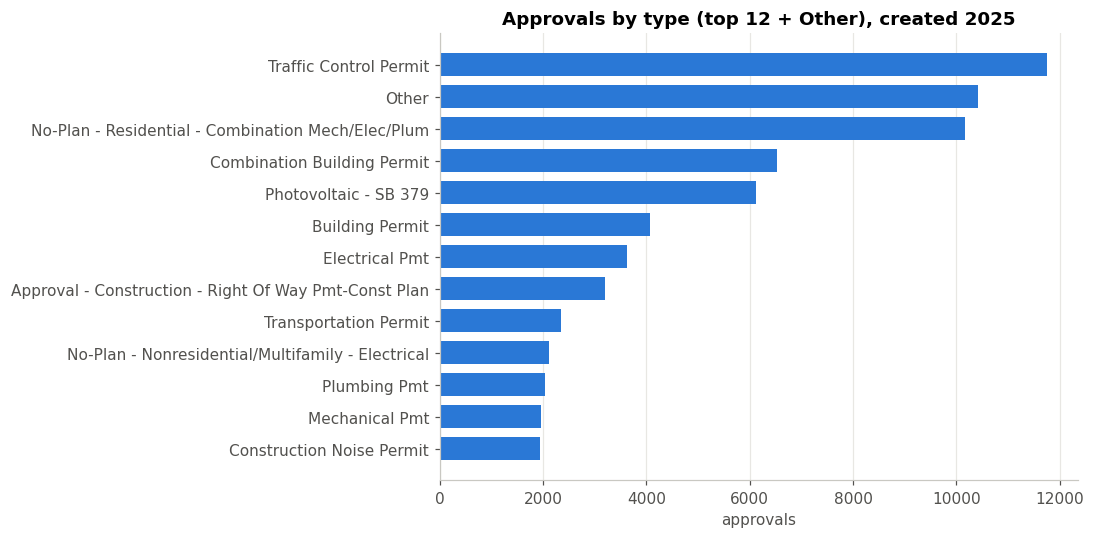

In [8]:
TOP_N = 12
top_types = df['APPROVAL_TYPE'].value_counts().index[:TOP_N]
df['TYPE_GRP'] = df['APPROVAL_TYPE'].where(df['APPROVAL_TYPE'].isin(top_types), 'Other')

counts = df['TYPE_GRP'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(counts.index[::-1], counts.values[::-1], color=ACCENT, height=0.7)
ax.set_title('Approvals by type (top 12 + Other), created 2025')
ax.set_xlabel('approvals')
ax.grid(axis='y', visible=False)
plt.tight_layout()

## 3. Date sanity checks

The file was pulled in early Oct 2026. The latest date in it is 2026-10-04, so I treat **2026-10-06** as "today" for the future-date check.

In [9]:
AS_OF = pd.Timestamp('2026-10-06')
df[DATE_COLS].agg(['min', 'max', 'count']).T

,min,max,count
PROJECT_CREATE_DATE,2020-03-13 00:00:00,2026-09-22 00:00:00,27916
PROJECT_DEEMEDCOMPLETE_DATE,2018-08-23 00:00:00,2026-09-17 00:00:00,26203
APPROVAL_CREATE_DATE,2025-01-01 00:00:00,2025-12-31 00:00:00,66317
APPROVAL_ISSUE_DATE,2025-01-01 00:00:00,2026-10-04 00:00:00,52579
APPROVAL_CLOSE_DATE,2025-01-06 00:00:00,2026-10-03 00:00:00,22346
APPROVAL_EXPIRE_DATE,2023-09-12 00:00:00,2028-09-29 00:00:00,36530


In [10]:
checks = {
    'issue < approval create':        df['APPROVAL_ISSUE_DATE'] < df['APPROVAL_CREATE_DATE'],
    'close < issue':                  df['APPROVAL_CLOSE_DATE'] < df['APPROVAL_ISSUE_DATE'],
    'close < approval create':        df['APPROVAL_CLOSE_DATE'] < df['APPROVAL_CREATE_DATE'],
    'deemed complete < project create': df['PROJECT_DEEMEDCOMPLETE_DATE'] < df['PROJECT_CREATE_DATE'],
    'approval create < project create': df['APPROVAL_CREATE_DATE'] < df['PROJECT_CREATE_DATE'],
    'expire < approval create':       df['APPROVAL_EXPIRE_DATE'] < df['APPROVAL_CREATE_DATE'],
    'any non-expire date in future':  (df[DATE_COLS[:-1]] > AS_OF).any(axis=1),
    'placeholder-ish (<2000 or >2030)': ((df[DATE_COLS] < '2000-01-01') | (df[DATE_COLS] > '2030-12-31')).any(axis=1),
}
pd.Series({k: int(v.sum()) for k, v in checks.items()}).to_frame('n_rows')

,n_rows
issue < approval create,0
close < issue,0
close < approval create,0
deemed complete < project create,14
approval create < project create,6
expire < approval create,21
any non-expire date in future,0
placeholder-ish (<2000 or >2030),0


In [11]:
# Look at the odd ones directly
cols = ['APPROVAL_TYPE', 'APPROVAL_STATUS'] + DATE_COLS
print('approval created BEFORE its project:')
display(df.loc[checks['approval create < project create'], cols].head())
print('deemed complete before project create:')
display(df.loc[checks['deemed complete < project create'], cols].head())

approval created BEFORE its project:


,APPROVAL_TYPE,APPROVAL_STATUS,PROJECT_CREATE_DATE,PROJECT_DEEMEDCOMPLETE_DATE,APPROVAL_CREATE_DATE,APPROVAL_ISSUE_DATE,APPROVAL_CLOSE_DATE,APPROVAL_EXPIRE_DATE
24289,Approval - Construction - Grading Pmt,Closed,2026-07-29,NaT,2025-02-27,2025-09-05,2026-08-27,NaT
35045,Approval - Construction - Grading-Right of Way Pmt,Issued,2026-08-13,NaT,2025-02-28,2025-08-06,NaT,NaT
44491,Approval - Construction - Grading-Right of Way Pmt,Issued,2026-09-22,2025-07-29,2025-07-29,2025-08-25,NaT,2027-08-20
45844,Approval - Process - Agreement,Opened,2026-07-30,2020-03-16,2025-06-12,NaT,NaT,NaT
48547,Approval - Process - Agreement,Opened,2026-07-30,2020-03-16,2025-06-12,NaT,NaT,NaT


deemed complete before project create:


,APPROVAL_TYPE,APPROVAL_STATUS,PROJECT_CREATE_DATE,PROJECT_DEEMEDCOMPLETE_DATE,APPROVAL_CREATE_DATE,APPROVAL_ISSUE_DATE,APPROVAL_CLOSE_DATE,APPROVAL_EXPIRE_DATE
1908,Approval - Construction - Fire Pmt - Alarm,Closed,2024-05-01,2021-02-17,2025-06-10,2025-06-20,2026-07-14,NaT
38300,Approval - Process - Agreement,Issued,2024-06-14,2019-08-22,2025-04-17,2025-06-13,NaT,NaT
44491,Approval - Construction - Grading-Right of Way Pmt,Issued,2026-09-22,2025-07-29,2025-07-29,2025-08-25,NaT,2027-08-20
45844,Approval - Process - Agreement,Opened,2026-07-30,2020-03-16,2025-06-12,NaT,NaT,NaT
48547,Approval - Process - Agreement,Opened,2026-07-30,2020-03-16,2025-06-12,NaT,NaT,NaT


In [12]:
# Check for placeholder dates showing up as suspicious spikes on a single day
for c in DATE_COLS:
    top = df[c].value_counts().head(1)
    print(f'{c:30s} most common = {top.index[0].date()}  ({top.iloc[0]} rows)')

PROJECT_CREATE_DATE            most common = 2025-12-23  (324 rows)
PROJECT_DEEMEDCOMPLETE_DATE    most common = 2025-12-23  (234 rows)
APPROVAL_CREATE_DATE           most common = 2025-12-29  (629 rows)
APPROVAL_ISSUE_DATE            most common = 2025-03-05  (349 rows)
APPROVAL_CLOSE_DATE            most common = 2025-12-10  (137 rows)
APPROVAL_EXPIRE_DATE           most common = 2027-03-29  (476 rows)


## 4. Durations

All durations are in calendar days. Negative durations come from bad date ordering (section 3), so I set them to NaN.

In [13]:
def days(start, end):
    d = (df[end] - df[start]).dt.days
    return d.where(d >= 0)

df['completeness_days'] = days('PROJECT_CREATE_DATE', 'PROJECT_DEEMEDCOMPLETE_DATE')
df['turnaround_days']   = days('APPROVAL_CREATE_DATE', 'APPROVAL_ISSUE_DATE')
df['build_days']        = days('APPROVAL_ISSUE_DATE', 'APPROVAL_CLOSE_DATE')

DUR = ['completeness_days', 'turnaround_days', 'build_days']
# Permits that go through plan review. Most of the rest are issued the same day.
PLAN_TYPES = ['Building Permit', 'Combination Building Permit']
df['is_plan_review'] = df['APPROVAL_TYPE'].isin(PLAN_TYPES)
df[DUR].describe(percentiles=[.5, .75, .9, .99]).round(1).T

,count,mean,std,min,50%,75%,90%,99%,max
completeness_days,26189.0,22.7,34.7,0.0,13.0,28.0,53.0,169.1,1158.0
turnaround_days,52579.0,43.3,89.1,0.0,1.0,35.0,157.0,409.2,626.0
build_days,22299.0,82.4,92.0,0.0,49.0,113.0,209.0,421.0,605.0


In [14]:
print('Share of turnarounds that are same-day (0 days):',
      f"{(df['turnaround_days'] == 0).mean() / df['turnaround_days'].notna().mean():.1%}")

Share of turnarounds that are same-day (0 days): 39.5%


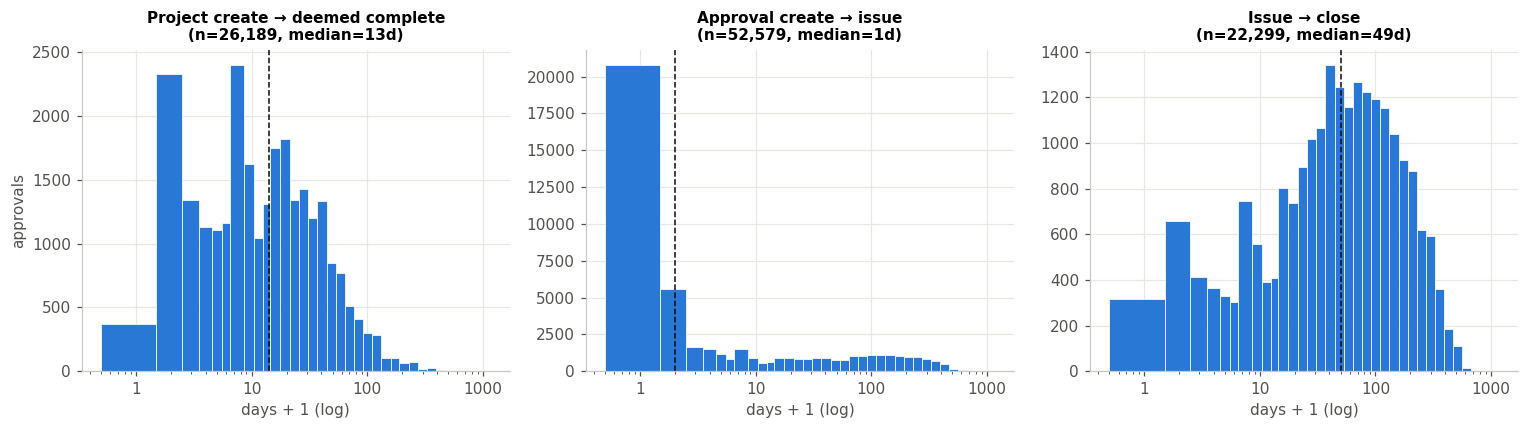

In [15]:
# Log-spaced histograms. Plot days+1 so same-day (0) records still show up.
labels = {'completeness_days': 'Project create → deemed complete',
          'turnaround_days':   'Approval create → issue',
          'build_days':        'Issue → close'}
bins = np.unique(np.round(np.logspace(0, np.log10(df[DUR].max().max() + 2), 40))) - 0.5  # integer-aligned

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, c in zip(axes, DUR):
    s = df[c].dropna() + 1
    ax.hist(s, bins=bins, color=ACCENT, edgecolor='white', linewidth=0.5)
    ax.set_xscale('log')
    ax.axvline(s.median(), color='#0b0b0b', lw=1, ls='--')
    ax.set_title(f'{labels[c]}\n(n={len(s):,}, median={s.median()-1:.0f}d)', fontsize=10)
    ax.set_xlabel('days + 1 (log)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
axes[0].set_ylabel('approvals')
plt.tight_layout()

**Meeting chart #1: turnaround distribution by type.** I show one box per type group on a log axis. Boxes are sorted by median and annotated with n. These numbers are only for *issued* approvals, so they are biased low (see section 5).

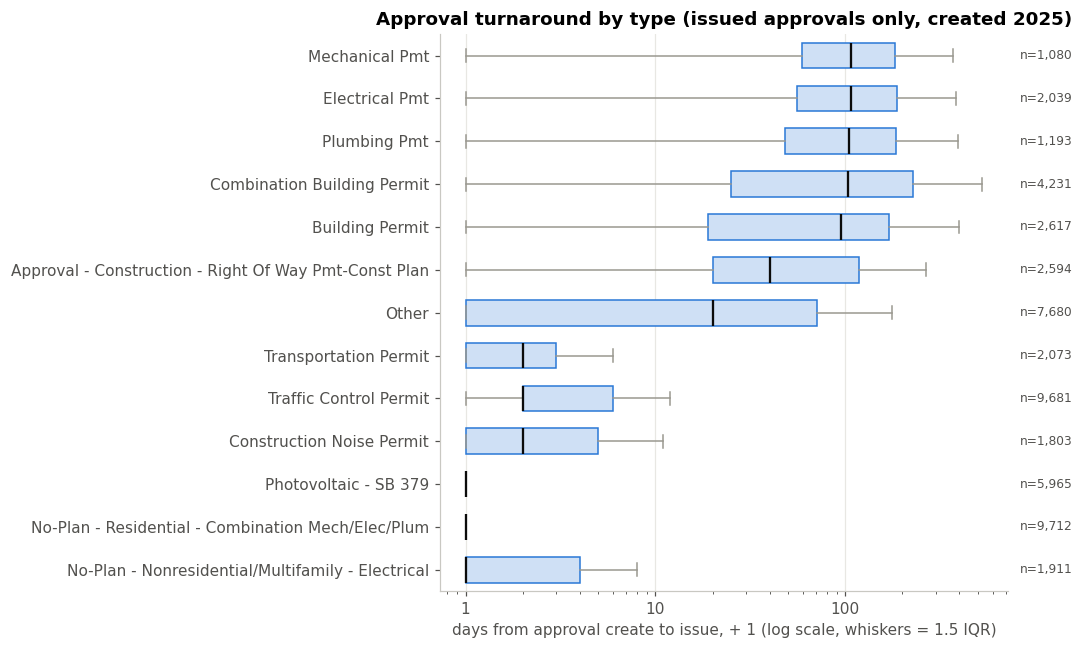

In [16]:
t = df.dropna(subset=['turnaround_days'])
order = t.groupby('TYPE_GRP')['turnaround_days'].median().sort_values().index
data = [t.loc[t['TYPE_GRP'] == g, 'turnaround_days'] + 1 for g in order]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(data, vert=False, tick_labels=order, showfliers=False, widths=0.6,
           patch_artist=True,
           boxprops=dict(facecolor='#cfe0f5', edgecolor=ACCENT),
           medianprops=dict(color='#0b0b0b', lw=1.5),
           whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
for i, d in enumerate(data, 1):
    ax.text(1.02, i, f'n={len(d):,}', transform=ax.get_yaxis_transform(), va='center', fontsize=8, color='#52514e')
ax.set_xlabel('days from approval create to issue, + 1 (log scale, whiskers = 1.5 IQR)')
ax.set_title('Approval turnaround by type (issued approvals only, created 2025)')
ax.grid(axis='y', visible=False)
plt.tight_layout()

In [17]:
def p90(s): return s.quantile(.9)

summary = (df.groupby('TYPE_GRP')
             .agg(n=('APPROVAL_ID', 'size'),
                  pct_issued=('APPROVAL_ISSUE_DATE', lambda s: s.notna().mean() * 100),
                  turnaround_med=('turnaround_days', 'median'),
                  turnaround_p90=('turnaround_days', p90),
                  completeness_med=('completeness_days', 'median'),
                  completeness_p90=('completeness_days', p90),
                  build_med=('build_days', 'median'),
                  build_p90=('build_days', p90))
             .sort_values('turnaround_med')
             .round(1))
summary

,n,pct_issued,turnaround_med,turnaround_p90,completeness_med,completeness_p90,build_med,build_p90
TYPE_GRP,,,,,,,,
No-Plan - Nonresidential/Multifamily - Electrical,2111,90.5,0.0,31.0,NaN,NaN,39.0,162.0
No-Plan - Residential - Combination Mech/Elec/Plum,10176,95.4,0.0,2.0,NaN,NaN,26.0,105.0
Photovoltaic - SB 379,6122,97.4,0.0,2.0,NaN,NaN,41.0,135.0
Construction Noise Permit,1940,92.9,1.0,6.0,NaN,NaN,NaN,NaN
Traffic Control Permit,11760,82.3,1.0,11.0,NaN,NaN,46.5,210.6
Transportation Permit,2350,88.2,1.0,4.0,NaN,NaN,NaN,NaN
Other,10426,73.7,19.0,205.0,14.0,57.0,37.0,177.9
Approval - Construction - Right Of Way Pmt-Const Plan,3197,81.1,39.0,244.7,2.0,25.0,196.0,375.6
Building Permit,4077,64.2,94.0,285.0,13.0,53.0,102.0,262.4


## 5. Censoring check

An approval with no issue date is either still **pending**, which is right-censored, or it was **cancelled or withdrawn** and will never be issued. I split those two cases using the status.

In [18]:
no_issue = df['APPROVAL_ISSUE_DATE'].isna()
print(f'Null issue date: {no_issue.sum():,} of {len(df):,} ({no_issue.mean():.1%})')
df.loc[no_issue, 'APPROVAL_STATUS'].value_counts().to_frame('n_without_issue_date')

Null issue date: 13,738 of 66,317 (20.7%)


,n_without_issue_date
APPROVAL_STATUS,
Opened,6746
Cancelled,3883
Approved Upon Final Payment,1329
Open,302
Issued,244
Recheck Required,232
Pending Invoice Payment,206
Invoice Paid,147
Cancelled Application Expired,139


In [19]:
dead = df['APPROVAL_STATUS'].str.contains('Cancel|Withdraw|Expired|Denied|Void', na=False)
df['issue_state'] = np.select(
    [~no_issue, dead],
    ['issued', 'never (cancelled/expired)'],
    default='pending (censored)')
df['issue_state'].value_counts(normalize=True).mul(100).round(1).to_frame('pct')

,pct
issue_state,
issued,79.3
pending (censored),14.5
never (cancelled/expired),6.3


**Meeting chart #2: censoring share by creation month.** A few statuses such as `Closed` and `Issued` also have no issue date. That's a small data gap, and I count those rows as pending here. Approvals created late in 2025 have had less time to be issued, so a larger share of them is still pending. Any average computed only on issued approvals favors the fast ones. The bias is worst for the late months and for slow approval types.

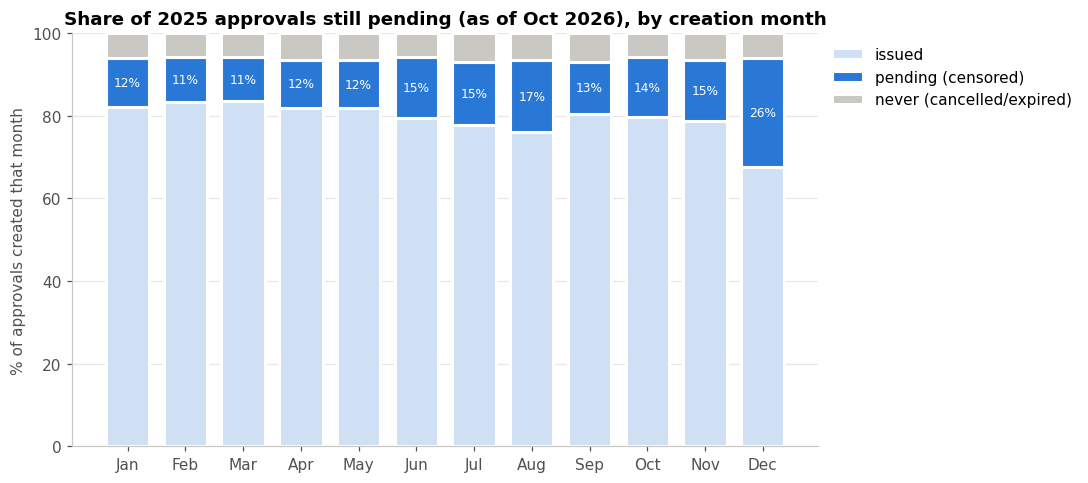

In [20]:
df['create_month'] = df['APPROVAL_CREATE_DATE'].dt.to_period('M')
cens = (pd.crosstab(df['create_month'], df['issue_state'], normalize='index') * 100)
cens = cens[['issued', 'pending (censored)', 'never (cancelled/expired)']]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = cens.index.strftime('%b')
bottom = np.zeros(len(cens))
colors = {'issued': '#cfe0f5', 'pending (censored)': ACCENT, 'never (cancelled/expired)': '#c9c8c2'}
for col in cens.columns:
    ax.bar(x, cens[col], bottom=bottom, color=colors[col], label=col, edgecolor='white', linewidth=2, width=0.75)
    bottom += cens[col].values
for i, v in enumerate(cens['pending (censored)']):
    ax.text(i, cens['issued'].iloc[i] + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white')
ax.set_ylabel('% of approvals created that month')
ax.set_title('Share of 2025 approvals still pending (as of Oct 2026), by creation month')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
ax.set_ylim(0, 100)
ax.grid(axis='x', visible=False)
plt.tight_layout()

In [21]:
# Pending share by type. Slow types have the most censoring.
(pd.crosstab(df['TYPE_GRP'], df['issue_state'], normalize='index').mul(100).round(1)
   .sort_values('pending (censored)', ascending=False))

issue_state,issued,never (cancelled/expired),pending (censored)
TYPE_GRP,,,
Electrical Pmt,56.3,7.9,35.8
Mechanical Pmt,55.0,12.4,32.6
Combination Building Permit,64.8,3.9,31.3
Plumbing Pmt,58.6,10.1,31.3
Building Permit,64.2,7.4,28.4
Other,73.7,5.2,21.1
Approval - Construction - Right Of Way Pmt-Const Plan,81.1,4.2,14.7
Transportation Permit,88.2,1.5,10.3
No-Plan - Nonresidential/Multifamily - Electrical,90.5,1.7,7.8


**Caveat:** this file only has approvals *created* in 2025, so every median here is right-censored. For conclusions about duration, pull the 2020–2024 files, where nearly everything has resolved, or use survival methods such as Kaplan-Meier that treat pending approvals as censored instead of dropping them.

## 6. Seasonality and trend

In [22]:
monthly = df.groupby('create_month').agg(
    created=('APPROVAL_ID', 'size'),
    median_turnaround_all=('turnaround_days', 'median'))
plan_m = df[df['is_plan_review']].groupby('create_month')['turnaround_days']
monthly['plan_created'] = df[df['is_plan_review']].groupby('create_month').size()
monthly['plan_median_turnaround'] = plan_m.median()
monthly['plan_p90_turnaround'] = plan_m.quantile(.9)
monthly

,created,median_turnaround_all,plan_created,plan_median_turnaround,plan_p90_turnaround
create_month,,,,,
2025-01,5594,2.0,845,112.5,399.5
2025-02,5239,2.0,825,103.5,396.8
2025-03,5516,1.0,1047,66.5,333.6
2025-04,5431,1.0,852,83.5,350.6
2025-05,5466,2.0,926,104.0,339.4
2025-06,5212,2.0,848,101.5,322.0
2025-07,5730,2.0,984,89.5,322.9
2025-08,5724,1.0,844,92.0,277.0
2025-09,5856,1.0,876,102.0,266.6


**Meeting chart #3: monthly volume and turnaround.** These are two separate panels. Volume and days are different units, so they don't share an axis. About 40% of all approvals are issued the same day, which keeps the overall median at 1–2 days. For that reason, the turnaround panel uses **Building + Combination Building permits only**. The values for late months are biased low by censoring, which you can see as the p90 drifting down.

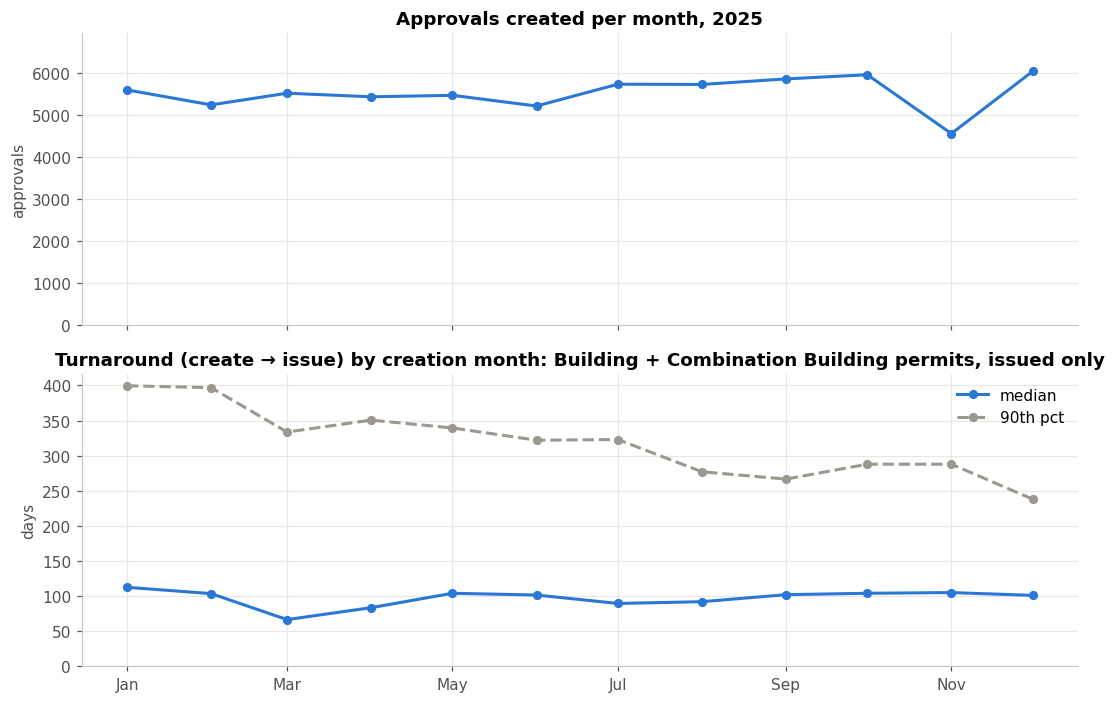

In [23]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
x = monthly.index.to_timestamp()

a1.plot(x, monthly['created'], color=ACCENT, lw=2, marker='o', ms=5)
a1.set_ylim(0, monthly['created'].max() * 1.15)
a1.set_title('Approvals created per month, 2025')
a1.set_ylabel('approvals')

a2.plot(x, monthly['plan_median_turnaround'], color=ACCENT, lw=2, marker='o', ms=5, label='median')
a2.plot(x, monthly['plan_p90_turnaround'], color=MUTED, lw=2, marker='o', ms=5, ls='--', label='90th pct')
a2.set_ylim(0, None)
a2.set_title('Turnaround (create → issue) by creation month: Building + Combination Building permits, issued only')
a2.set_ylabel('days')
a2.legend(frameon=False)
a2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
plt.tight_layout()

In [24]:
# Same thing for a few major types (median only)
main_types = df['TYPE_GRP'].value_counts().index[:5]
piv = (df[df['TYPE_GRP'].isin(main_types)]
       .pivot_table(index='create_month', columns='TYPE_GRP', values='turnaround_days', aggfunc='median'))
piv.round(1)

TYPE_GRP,Combination Building Permit,No-Plan - Residential - Combination Mech/Elec/Plum,Other,Photovoltaic - SB 379,Traffic Control Permit
create_month,,,,,
2025-01,109.0,0.0,20.0,0.0,2.0
2025-02,100.0,0.0,20.0,0.0,1.0
2025-03,43.0,0.0,21.0,0.0,1.0
2025-04,86.0,0.0,17.0,0.0,1.0
2025-05,147.0,0.0,16.0,0.0,3.0
2025-06,132.5,0.0,17.0,0.0,2.0
2025-07,102.0,0.0,20.0,0.0,1.0
2025-08,105.0,0.0,22.0,0.0,1.0
2025-09,119.5,0.0,21.0,0.0,1.0


In [25]:
# Day of week, as a simple seasonality signal
df['APPROVAL_CREATE_DATE'].dt.day_name().value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).to_frame('created')

,created
APPROVAL_CREATE_DATE,
Monday,12782
Tuesday,14042
Wednesday,13880
Thursday,12691
Friday,11753
Saturday,516
Sunday,653


Only one creation year is in this file, so I can't do a by-year trend yet. That needs the 2020–2024 files.

## 7. Complexity vs. duration

`APPROVAL_DU_NET_CHANGE` is 100% null in this file, so I use `APPROVAL_ADU_TOTAL` instead. Zeros are mostly placeholders for "not applicable", so I drop non-positive values before taking logs.

In [26]:
CX = ['APPROVAL_VALUATION', 'APPROVAL_FLOOR_AREA', 'APPROVAL_STORIES', 'APPROVAL_DU_NET_CHANGE', 'APPROVAL_ADU_TOTAL']
pd.DataFrame({
    'non_null': df[CX].notna().sum(),
    'positive': (df[CX] > 0).sum(),
    'positive_with_turnaround': ((df[CX] > 0) & df[['turnaround_days']].notna().values).sum(),
})

,non_null,positive,positive_with_turnaround
APPROVAL_VALUATION,8432,8415,5984
APPROVAL_FLOOR_AREA,218,174,73
APPROVAL_STORIES,1133,1114,539
APPROVAL_DU_NET_CHANGE,0,0,0
APPROVAL_ADU_TOTAL,9244,2012,1043


In [27]:
rows = []
for c in CX:
    sub = df.loc[(df[c] > 0) & df['turnaround_days'].notna(), [c, 'turnaround_days']]
    if len(sub) >= 10:
        rho, p = spearmanr(sub[c], sub['turnaround_days'])
        rows.append({'feature': c, 'n': len(sub), 'spearman_rho': round(rho, 3), 'p_value': p})
    else:
        rows.append({'feature': c, 'n': len(sub), 'spearman_rho': np.nan, 'p_value': np.nan})
pd.DataFrame(rows).set_index('feature')

,n,spearman_rho,p_value
feature,,,
APPROVAL_VALUATION,5984,0.533,0.000000e+00
APPROVAL_FLOOR_AREA,73,0.172,1.453285e-01
APPROVAL_STORIES,539,0.202,2.300923e-06
APPROVAL_DU_NET_CHANGE,0,NaN,NaN
APPROVAL_ADU_TOTAL,1043,0.287,3.120282e-21


**Meeting chart #4: complexity scatter.** Valuation is the only complexity field with real coverage.

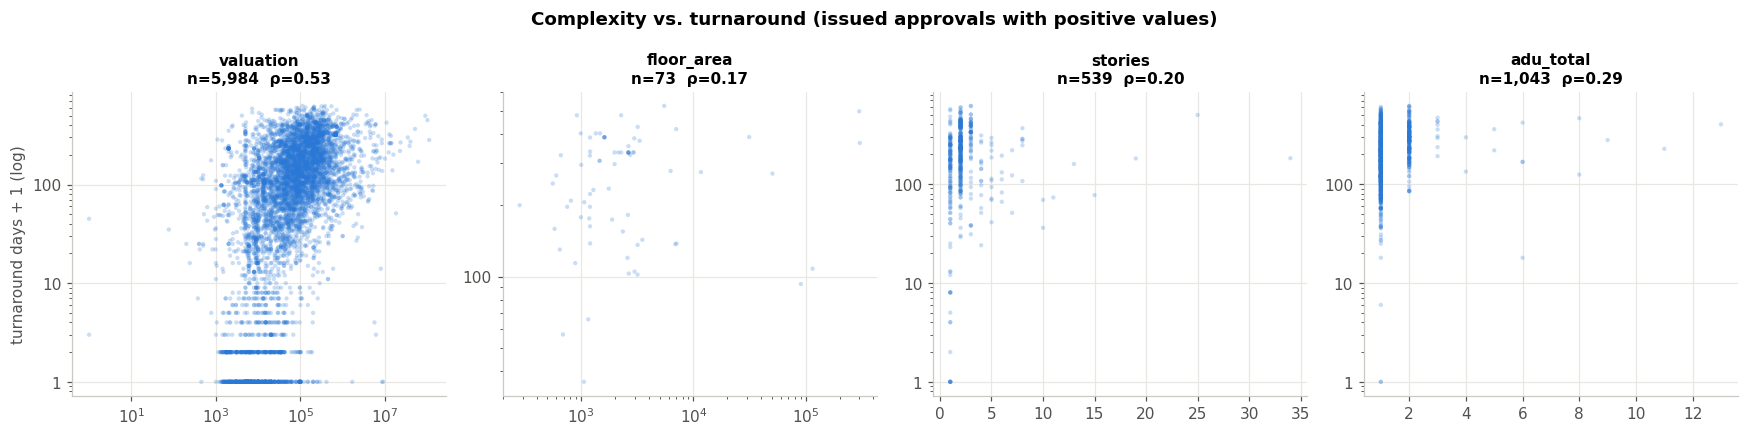

In [28]:
plot_cx = ['APPROVAL_VALUATION', 'APPROVAL_FLOOR_AREA', 'APPROVAL_STORIES', 'APPROVAL_ADU_TOTAL']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, c in zip(axes, plot_cx):
    sub = df.loc[(df[c] > 0) & df['turnaround_days'].notna(), [c, 'turnaround_days']]
    ax.scatter(sub[c], sub['turnaround_days'] + 1, s=8, alpha=0.25, color=ACCENT, edgecolors='none')
    if c in ('APPROVAL_VALUATION', 'APPROVAL_FLOOR_AREA'):
        ax.set_xscale('log')
    ax.set_yscale('log')
    rho = spearmanr(sub[c], sub['turnaround_days'])[0] if len(sub) > 10 else np.nan
    ax.set_title(f"{c.replace('APPROVAL_', '').lower()}\nn={len(sub):,}  ρ={rho:.2f}", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:g}'))
axes[0].set_ylabel('turnaround days + 1 (log)')
fig.suptitle('Complexity vs. turnaround (issued approvals with positive values)', fontweight='bold')
plt.tight_layout()

In [29]:
# Valuation could just be a proxy for permit type. Check rho within the main types that carry valuation.
v = df[(df['APPROVAL_VALUATION'] > 0) & df['turnaround_days'].notna()]
(v.groupby('TYPE_GRP')
  .filter(lambda g: len(g) >= 50)
  .groupby('TYPE_GRP')
  .apply(lambda g: pd.Series({'n': len(g), 'rho': spearmanr(g['APPROVAL_VALUATION'], g['turnaround_days'])[0],
                              'median_valuation': g['APPROVAL_VALUATION'].median()}), include_groups=False)
  .round(3).sort_values('n', ascending=False))

,n,rho,median_valuation
TYPE_GRP,,,
Combination Building Permit,3497.0,0.578,64279.96
Building Permit,2466.0,0.515,50000.00


## 8. Who's applying

The raw names have case and whitespace variants (e.g. `ASI HASTINGS` vs `ASI Hastings`), so I normalize them first.

In [30]:
def norm_holder(s):
    s = s.str.upper().str.strip()
    s = s.str.replace(r'[.,]', '', regex=True).str.replace(r'\s+', ' ', regex=True)
    s = s.str.replace(r'\b(INC|LLC|CORP|CO|LP|LTD)$', '', regex=True).str.strip()
    return s

df['HOLDER'] = norm_holder(df['APPROVAL_PERMIT_HOLDER'])
print('raw distinct:', df['APPROVAL_PERMIT_HOLDER'].nunique(), '| normalized distinct:', df['HOLDER'].nunique())
print(f"null holder: {df['HOLDER'].isna().mean():.1%}")
df['HOLDER'].value_counts().head(20).to_frame('approvals')

raw distinct: 10550 | normalized distinct: 9752
null holder: 20.0%


,approvals
HOLDER,
SDG&E,5272
AT&T CALIFORNIA,1547
ASI HASTINGS,1358
SUNRUN,1199
CALIFORNIA MECHANICAL,705
WALTER ANDERSON PLUMBING,645
COX COMMUNICATIONS,562
ARCHON ENERGY SOLUTIONS,542
BAKER ELECTRIC HOME ENERGY,511


top    1 holders file 9.9% of approvals that have a holder
top   10 holders file 24.1% of approvals that have a holder
top   50 holders file 37.3% of approvals that have a holder
top  100 holders file 44.2% of approvals that have a holder
top  500 holders file 63.1% of approvals that have a holder
holders with only 1 approval: 5,752 (59.0% of holders)


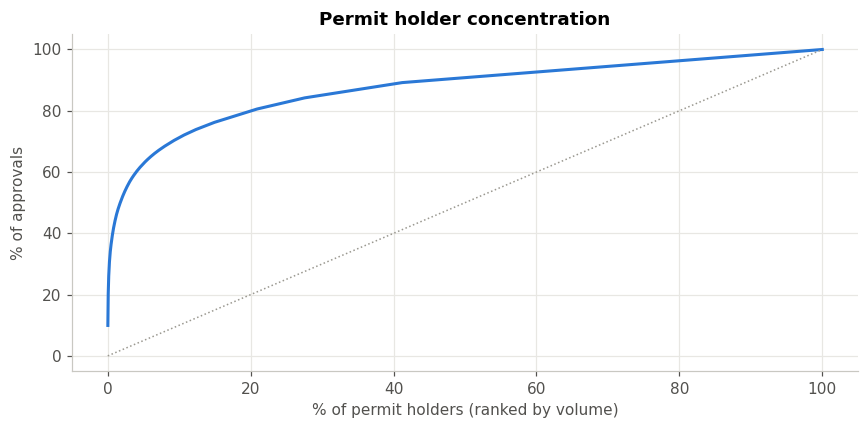

In [31]:
hc = df['HOLDER'].value_counts()
share = hc.cumsum() / hc.sum()
for k in [1, 10, 50, 100, 500]:
    print(f'top {k:>4} holders file {share.iloc[k-1]:.1%} of approvals that have a holder')
print(f'holders with only 1 approval: {(hc == 1).sum():,} ({(hc == 1).mean():.1%} of holders)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(share) + 1) / len(share) * 100, share.values * 100, color=ACCENT, lw=2)
ax.plot([0, 100], [0, 100], color=MUTED, lw=1, ls=':')
ax.set_xlabel('% of permit holders (ranked by volume)')
ax.set_ylabel('% of approvals')
ax.set_title('Permit holder concentration')
plt.tight_layout()

In [32]:
# First look at the "experience" idea: holder volume bucket vs turnaround
bucket = pd.cut(df['HOLDER'].map(hc), [0, 1, 5, 20, 100, np.inf], labels=['1', '2-5', '6-20', '21-100', '100+'])
(df.assign(holder_volume=bucket)
   .groupby('holder_volume', observed=True)
   .agg(n=('APPROVAL_ID', 'size'),
        turnaround_med=('turnaround_days', 'median'),
        turnaround_p90=('turnaround_days', p90),
        pct_pending=('issue_state', lambda s: (s == 'pending (censored)').mean() * 100))
   .round(1))

,n,turnaround_med,turnaround_p90,pct_pending
holder_volume,,,,
1,5752,16.0,234.0,4.9
2-5,8213,30.0,254.0,5.9
6-20,8567,8.0,208.0,4.4
21-100,11217,2.0,111.0,4.5
100+,19300,0.0,17.7,1.9


This is confounded by type. High-volume holders like SDG&E and the solar installers file fast, simple permit types. A fair test compares holders within a type.

In [33]:
(df[df['TYPE_GRP'].isin(['Combination Building Permit', 'Building Permit'])]
   .assign(holder_volume=bucket)
   .groupby(['TYPE_GRP', 'holder_volume'], observed=True)['turnaround_days']
   .agg(['size', 'median', p90]).round(1))

size  median    p90
TYPE_GRP                    holder_volume                     
Building Permit             1               231   100.5  277.3
                            2-5             780   118.0  304.5
                            6-20            731   104.0  286.0
                            21-100          887    22.0  231.0
                            100+            209    29.0  165.0
Combination Building Permit 1              1608   122.0  305.9
                            2-5            1007   145.0  357.0
                            6-20            749   105.0  356.0
                            21-100          550    91.5  343.0
                            100+            416     0.0    3.0

## 9. Geography

In [34]:
geo_missing = df[['GIS_LATITUDE', 'GIS_LONGITUDE']].isna().any(axis=1)
print(f'missing lat/long: {geo_missing.sum():,} ({geo_missing.mean():.1%})')
df.loc[geo_missing, 'TYPE_GRP'].value_counts().head(8).to_frame('missing_geo_by_type')

missing lat/long: 2,218 (3.3%)


,missing_geo_by_type
TYPE_GRP,
Transportation Permit,2175
Other,18
Construction Noise Permit,10
Traffic Control Permit,8
No-Plan - Residential - Combination Mech/Elec/Plum,4
Photovoltaic - SB 379,1
Plumbing Pmt,1
No-Plan - Nonresidential/Multifamily - Electrical,1


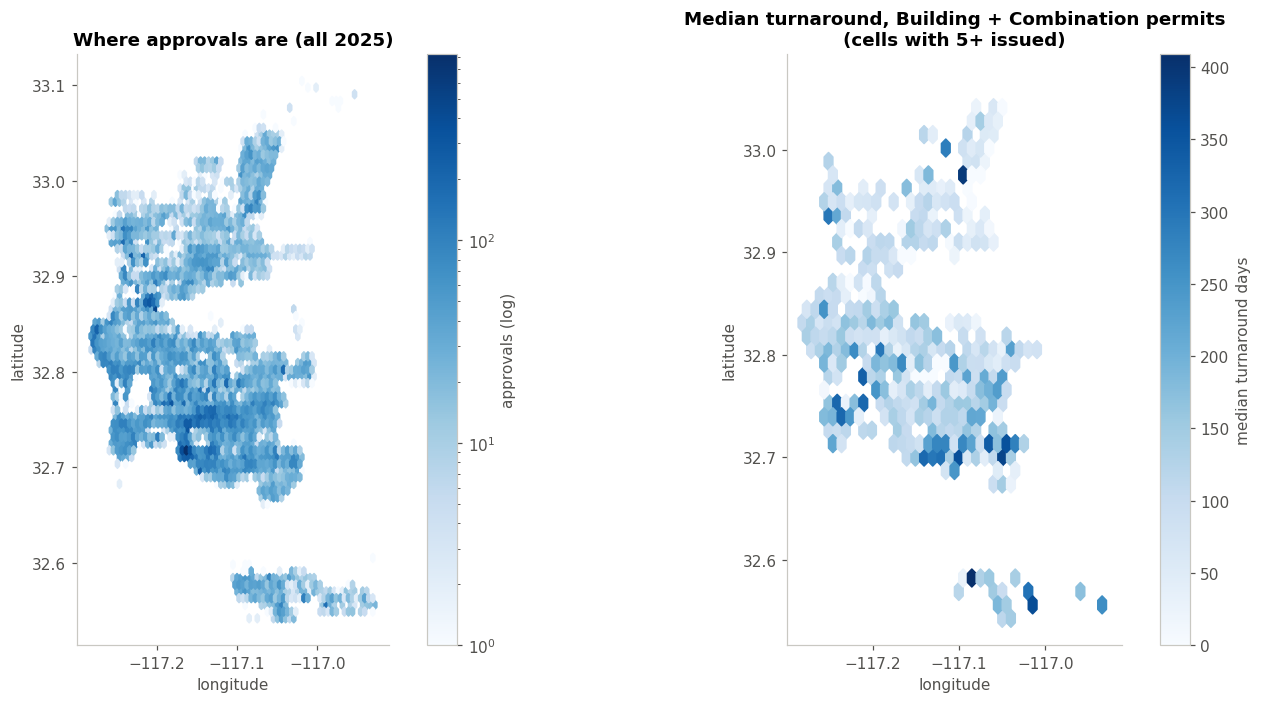

In [35]:
g = df[~geo_missing]
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
hb = axes[0].hexbin(g['GIS_LONGITUDE'], g['GIS_LATITUDE'], gridsize=70, bins='log', cmap='Blues', mincnt=1)
fig.colorbar(hb, ax=axes[0], label='approvals (log)')
axes[0].set_title('Where approvals are (all 2025)')

gi = g[g['is_plan_review']].dropna(subset=['turnaround_days'])
hb2 = axes[1].hexbin(gi['GIS_LONGITUDE'], gi['GIS_LATITUDE'], C=gi['turnaround_days'],
                     reduce_C_function=np.median, gridsize=35, cmap='Blues', mincnt=5)
fig.colorbar(hb2, ax=axes[1], label='median turnaround days')
axes[1].set_title('Median turnaround, Building + Combination permits\n(cells with 5+ issued)')
for ax in axes:
    ax.set_aspect(1 / np.cos(np.radians(32.8)))
    ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
    ax.grid(False)
plt.tight_layout()

## 10. Free text

In [36]:
STOP = set('''a an the and or of to for in on at by with from as is are be this that it its per
new existing exist ex proposed propose project approval permit permits no non s sf sq ft w
work all only into under over per pts prj see re rev 1 2 3 4 5 6 7 8 9 0 i ii iii
'''.split())

def top_words(series, n=30):
    c = Counter()
    for txt in series.dropna().str.lower():
        c.update(w for w in re.findall(r'[a-z][a-z0-9/&-]+', txt) if w not in STOP and len(w) > 2)
    return pd.Series(dict(c.most_common(n)))

def tw(col):
    return top_words(df[col]).rename_axis('word').reset_index(name='count')
pd.concat({'PROJECT_SCOPE': tw('PROJECT_SCOPE'), 'APPROVAL_SCOPE': tw('APPROVAL_SCOPE')}, axis=1)

PROJECT_SCOPE        APPROVAL_SCOPE       
            word  count           word  count
0       building  29172       building  30929
1     electrical  14971     electrical  15656
2       plumbing  10486       plumbing  11015
3     mechanical  10230     mechanical  10734
4        include  10172        include  10439
5    combination   6782    combination   7185
6            sdu   6365            sdu   6594
7          story   6070          story   6480
8          units   6016          units   6025
9         tenant   5298         tenant   5385
10   improvement   5116       interior   5265
11      interior   5011    improvement   5170
12    commercial   4593           mesa   4843
13          plan   4366     commercial   4691
14      includes   4345            adu   4565
15           adu   4290          scope   4538
16          mesa   4286       includes   4464
17         scope   4189          floor   4157
18    associated   4034    destination   4153
19         floor   3994        remodel   4076
20       remodel   3937     associated   4057
21          fire   3795           fire   3996
22        public   3673           plan   3895
23          wall   3520           unit   3748
24          area   3490       detached   3672
25         walls   3477          walls   3608
26          will   3433           wall   3606
27      detached   3392           will   3551
28  improvements   3288         public   3488
29          unit   3171       exterior   3289

In [37]:
# Keyword flags as candidate features
text = (df['PROJECT_SCOPE'].fillna('') + ' ' + df['APPROVAL_SCOPE'].fillna('') + ' ' + df['PROJECT_TITLE'].fillna('')).str.lower()
KEYWORDS = {
    'solar/pv':   r'\bsolar\b|\bpv\b|photovoltaic',
    'battery':    r'batter|\bess\b|energy storage',
    'adu/jadu':   r'\badu\b|\bjadu\b|accessory dwelling|companion unit',
    'remodel':    r'remodel|renovat|alteration',
    'addition':   r'\baddition\b',
    'pool/spa':   r'\bpool\b|\bspa\b',
    'tenant improvement': r'tenant improvement|\bti\b',
    'ev charger': r'\bev\b|electric vehicle|charger',
    'demolition': r'demo(?:lition|lish)?\b',
    'sign':       r'\bsign',
    'retaining wall': r'retaining wall',
    'construction change': r'construction change',
}
has_text = text.str.strip() != ''
print(f'rows with any scope/title text: {has_text.mean():.1%}')
kw = pd.DataFrame({k: text.str.contains(p, regex=True) for k, p in KEYWORDS.items()})
(pd.DataFrame({
    'n': kw.sum(),
    'pct_of_text_rows': (kw[has_text].mean() * 100).round(1),
    'turnaround_med': {k: df.loc[kw[k], 'turnaround_days'].median() for k in kw},
    'turnaround_p90': {k: df.loc[kw[k], 'turnaround_days'].quantile(.9) for k in kw},
 }).sort_values('n', ascending=False))

rows with any scope/title text: 47.0%


,n,pct_of_text_rows,turnaround_med,turnaround_p90
tenant improvement,5342,17.1,80.0,233.0
remodel,5126,16.5,82.0,289.0
demolition,3837,12.3,92.0,321.9
adu/jadu,3743,12.0,179.0,391.2
addition,2619,8.4,142.0,344.0
solar/pv,1396,4.5,18.0,286.0
sign,1090,3.5,35.0,231.0
pool/spa,972,3.1,97.0,316.0
retaining wall,763,2.4,192.0,417.0
battery,511,1.6,101.0,261.2


## 11. Working subset

I build a working dataframe here and leave the raw file untouched. The DU/ADU/JADU affordability tiers are 86% null and almost all zero when present, so I keep only the totals plus an `is_housing` flag.

In [38]:
DU_COLS = [c for c in df.columns if re.match(r'APPROVAL_(DU|ADU|JADU)_', c)]
pd.DataFrame({'pct_null': df[DU_COLS].isna().mean().mul(100).round(1),
              'n_nonzero': (df[DU_COLS].fillna(0) != 0).sum()}).sort_values('n_nonzero', ascending=False)

,pct_null,n_nonzero
APPROVAL_ADU_TOTAL,86.1,2012
APPROVAL_ADU_ABOVE_MODERATE,86.1,1877
APPROVAL_DU_ABOVE_MODERATE,86.1,713
APPROVAL_ADU_MODERATE,86.1,496
APPROVAL_ADU_BONUS,86.1,481
APPROVAL_JADU_ABOVE_MODERATE,86.1,142
APPROVAL_JADU_TOTAL,86.1,142
APPROVAL_DU_MODERATE,86.1,69
APPROVAL_DU_VERY_LOW,86.1,64
APPROVAL_DU_LOW,86.1,62


In [39]:
DROP = ['PROJECT_TRUST_ACCOUNT_NO', 'JOB_DRAWING_NUMBER', 'GIS_ADDRESS', 'APPROVAL_EXPIRE_DATE',
        'APPROVAL_CATEGORY_CODE', 'DEVELOPMENT_ID']  # last two: ~99.6% null
KEEP_DU = ['APPROVAL_DU_NET_CHANGE', 'APPROVAL_ADU_TOTAL', 'APPROVAL_JADU_TOTAL']

work = df.drop(columns=DROP + [c for c in DU_COLS if c not in KEEP_DU])
work['is_housing'] = ((df[DU_COLS].fillna(0) != 0).any(axis=1)
                      | df['JOB_BC_CODE_DESCRIPTION'].str.contains('Fam|Apt|Companion|DU', na=False))
print(work.shape)
print(f"is_housing: {work['is_housing'].mean():.1%}")
work.columns.tolist()

(66317, 38)
is_housing: 16.6%


['PROJECT_ID',
 'PROJECT_TYPE',
 'PROJECT_STATUS',
 'PROJECT_PROCESSING_CODE',
 'PROJECT_CREATE_DATE',
 'PROJECT_DEEMEDCOMPLETE_DATE',
 'PROJECT_TITLE',
 'PROJECT_SCOPE',
 'JOB_ID',
 'GIS_APN',
 'JOB_BC_CODE',
 'JOB_BC_CODE_DESCRIPTION',
 'GIS_LATITUDE',
 'GIS_LONGITUDE',
 'APPROVAL_ID',
 'APPROVAL_PROCESSING_CODE',
 'APPROVAL_TYPE',
 'APPROVAL_STATUS',
 'APPROVAL_SCOPE',
 'APPROVAL_CREATE_DATE',
 'APPROVAL_ISSUE_DATE',
 'APPROVAL_CLOSE_DATE',
 'APPROVAL_VALUATION',
 'APPROVAL_DU_NET_CHANGE',
 'APPROVAL_STORIES',
 'APPROVAL_FLOOR_AREA',
 'APPROVAL_ADU_TOTAL',
 'APPROVAL_JADU_TOTAL',
 'APPROVAL_PERMIT_HOLDER',
 'TYPE_GRP',
 'completeness_days',
 'turnaround_days',
 'build_days',
 'is_plan_review',
 'issue_state',
 'create_month',
 'HOLDER',
 'is_housing']

In [40]:
# JOB_BC_CODE looks like a building-classification code
df.groupby(['JOB_BC_CODE', 'JOB_BC_CODE_DESCRIPTION']).size().sort_values(ascending=False).head(15).to_frame('n')

,,n
JOB_BC_CODE,JOB_BC_CODE_DESCRIPTION,
4380.0,Add/Alt Tenant Improvements,6044
4333.0,Add/Alt Companion Unit/Acc Apt,2890
4341.0,"Add/Alt 1 or 2 Fam, No Chg DU",2547
4342.0,"Add/Alt 3+, No Chg DU",2045
1051.0,Five or More Family Apt,933
3295.0,ACC STRUCT- NON RES,548
3272.0,Signs - Permanent,541
1010.0,One Family Detached,325
3293.0,Pool or Spa/1 or 2 Family,313


## Summary

**Data health**
- 66,317 approvals, 54 columns. `APPROVAL_ID` is unique. Only 42% of approvals belong to a project. The rest are standalone permits: traffic control, no-plan MEP, PV, and transportation.
- Projects usually have a single approval (median 1, mean 1.7, max 266).
- Dates are clean. No issue dates fall before create dates, nothing is in the future, and there are no placeholder dates. About 40 rows have odd project-level ordering, for example a project created after its approval, which suggests project records get re-created or re-linked.
- `APPROVAL_DU_NET_CHANGE`, `APPROVAL_DU_FUTURE_DEMO`, and `JOB_DRAWING_NUMBER` are 100% null. Floor area and stories are close to 100% null.

**Durations**
- Turnaround (create → issue) is **bimodal**. About 40% are issued the same day: no-plan, PV, and traffic permits. Plan-review permits (Building, Combination, and the MEP permits tied to a project) have a median of about 100 days and a p90 of about 300 days.
- Completeness stage: median 13 days, p90 53 days. Issue → close: median 49 days, p90 209 days.

**Censoring**
- 20.7% have no issue date: about 14.5% are still pending and about 6% were cancelled or expired. For plan-review types, 35–45% are not yet issued, so their medians here are **biased low**. The p90 by creation month falls steadily from about 400 days to about 240 days, which is the censoring effect and not a real speed-up. We need the 2020–2024 files, or survival methods, before drawing conclusions about duration.

**Trend**
- Volume is flat at about 5–6k per month, with a dip in November and nearly zero filings on weekends. The plan-review median is stable at about 90–110 days, apart from a dip in March.

**Complexity**
- Valuation is the only complexity field with real coverage (n≈6k), and it correlates with turnaround: Spearman ρ≈0.53. The correlation holds *within* Building (0.52) and Combination (0.58) permits, so it isn't just a proxy for type. ADU count ρ≈0.29, stories ρ≈0.20.

**Applicants**
- Applicants are concentrated. The top 10 holders file 24% of approvals with a holder, and the top 100 file 44%. SDG&E alone files about 10%. High-volume holders are much faster, but that's mostly because of the permit types they file. Even *within* Building permits, holders with 21+ filings have a median of about 25 days versus about 100+ for one-off filers, so experience looks like a real candidate feature.

**Other**
- Geo is 3.3% missing, almost entirely Transportation Permits.
- Text keywords like ADU, retaining wall, and EV charger flag the slow projects (median about 180–190 days). Tenant improvement and remodel run around 80 days.

**Meeting charts:** turnaround by type (section 4), censoring share by month (section 5), monthly volume and turnaround (section 6), complexity scatter (section 7).